In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import heracles
import heracles.dices as dices
from heracles.io import read
from astropy.io import fits

font = {'size'   : 16}
import matplotlib
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 

# Validate Cats

In [2]:
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
n = 100 #config['nsims']
nside = 1024
lmax = config['lmax_partial']
lmin = config['lmin']
lmax_mask = config.get('lmax_mask', lmax)  # Default to lmax if not specified
mode = "lognormal" #config['mode']  # "lognormal" or "gaussian"
mask_type = "tr1" #config['mask_type']  # Default to 'dr1' if not specified
binned = False #True
apply_mask = True
nbins = 6

nsim = 6

output_path = f"{mode}_dices/"
output_path = "./masked_"+output_path

nlbins = config.get('nlbins', 20)  # Default to 20 if not specified
l = np.arange(lmax+1)
l_mask = np.arange(lmax_mask+1)
ledges = np.logspace(np.log10(lmin), np.log10(lmax), nlbins + 1)
lgrid = (ledges[1:] + ledges[:-1]) / 2
ledges_mask = np.logspace(np.log10(lmin), np.log10(lmax_mask), nlbins + 1)
lgrid_mask = (ledges_mask[1:] + ledges_mask[:-1]) / 2

In [3]:
SHE_cat = heracles.FitsCatalog(f"/pscratch/sd/j/jaimerz/lognormal_sims/tr1/cats/lognormal_sim_{nsim}_nside_{nside}/SHE.fits")
SHE_wb_cat = heracles.FitsCatalog(f"/pscratch/sd/j/jaimerz/lognormal_sims/tr1/cats/lognormal_sim_{nsim}_nside_{nside}/SHE_wb.fits")

In [4]:
tr1_mask = hp.read_map(f"/pscratch/sd/j/jaimerz/masks/tr1_mask_nside_{nside}.fits")
SHE_cat.visibility = tr1_mask
SHE_wb_cat.visibility = tr1_mask

In [5]:
SHE_cats = {i: SHE_cat[f"TOMBINID == {i}"] for i in range(1, 7)}
SHE_wb_cats = {i: SHE_wb_cat[f"TOMBINID == {i}"] for i in range(1, 7)}

In [6]:
import heracles.healpy
mapper = heracles.healpy.HealpixMapper(nside, lmax)

SHE_fields = {
    "SHE": heracles.Shears(
        mapper,
        "RA",
        "DEC",
        "E1",
        "E2",
        mask="WHT",
    )
}

In [7]:
theory_cls = heracles.read("/pscratch/sd/j/jaimerz/lognormal_sims/theory_camb.fits")
fsky=np.sum(tr1_mask)/len(tr1_mask)
print(fsky)

0.009183009465535482


In [8]:
SHE_data = heracles.map_catalogs(SHE_fields, SHE_cats)
SHE_wb_data = heracles.map_catalogs(SHE_fields, SHE_wb_cats)

In [9]:
SHE_alms = heracles.transform(SHE_fields, SHE_data)
SHE_wb_alms = heracles.transform(SHE_fields, SHE_wb_data)

In [10]:
cat_cls = heracles.angular_power_spectra(SHE_alms)
cat_cls_wb = heracles.angular_power_spectra(SHE_wb_alms)

In [11]:
map_cls = heracles.read(f"/pscratch/sd/j/jaimerz/lognormal_sims/tr1/cls/cls_data_{nsim}_lmax_3000.fits")
map_cls_wb = heracles.read(f"/pscratch/sd/j/jaimerz/lognormal_sims/tr1/cls/cls_data_wb_{nsim}_lmax_3000.fits")

[]

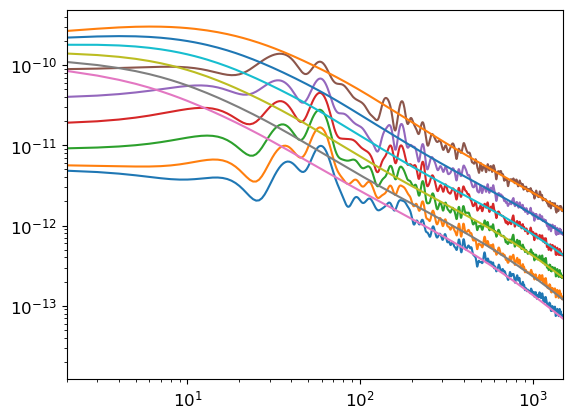

In [12]:
plt.plot(np.array([map_cls["SHE", "SHE", i, i][0, 0] for i in range(1, 6+1)]).T)
plt.plot(np.array([fsky*theory_cls[f"W{i}xW{i}"] for i in np.arange(1, 6+1)]).T)
plt.xlim(2, 1500)
plt.loglog()

In [16]:
cat_cls["SHE", "SHE", 1, 1].array.dtype.metadata

mappingproxy({'geometry_1': 'healpix',
              'kernel_1': 'healpix',
              'nside_1': 1024,
              'lmax_1': 3000,
              'deconv_1': True,
              'spin_1': 2,
              'catalog_1': None,
              'wbar_1': np.float64(59.17295692736414),
              'musq_1': np.float64(0.14551406771183806),
              'dens_1': np.float64(59250847.57137596),
              'fsky_1': np.float64(0.009183009465535482),
              'geometry_2': 'healpix',
              'kernel_2': 'healpix',
              'nside_2': 1024,
              'lmax_2': 3000,
              'deconv_2': True,
              'spin_2': 2,
              'catalog_2': None,
              'wbar_2': np.float64(59.17295692736414),
              'musq_2': np.float64(0.14551406771183806),
              'dens_2': np.float64(59250847.57137596),
              'fsky_2': np.float64(0.009183009465535482),
              'bias': np.float64(1.1276269588858377e-11)})

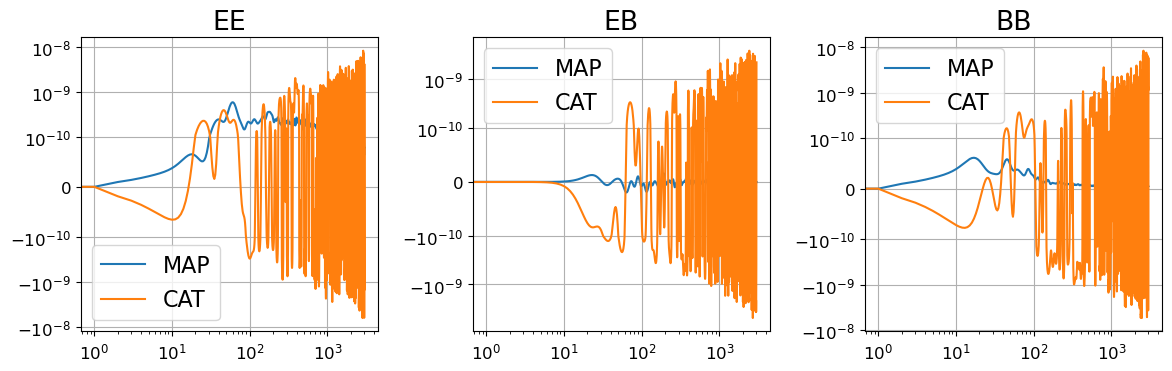

In [14]:
# list of function pairs for each panel
func_pairs = [
    ("EE", map_cls[("SHE", "SHE", 1, 1)][0,0], cat_cls[("SHE", "SHE", 1, 1)][0,0]),
    ("EB", map_cls[("SHE", "SHE", 1, 1)][0,1], cat_cls[("SHE", "SHE", 1, 1)][0,1]),
    ("BB", map_cls[("SHE", "SHE", 1, 1)][1,1], cat_cls[("SHE", "SHE", 1, 1)][1,1]),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
l = np.arange(lmax+1)
for ax, (f, fa, fb) in zip(axes.flat, func_pairs):
    ax.plot(l, l*fa, label=f"MAP")
    ax.plot(l, l*fb, label=f"CAT")
    ax.set_title(f)
    ax.legend()
    ax.grid(True)
    ax.set_yscale("symlog", linthresh=1E-10)
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

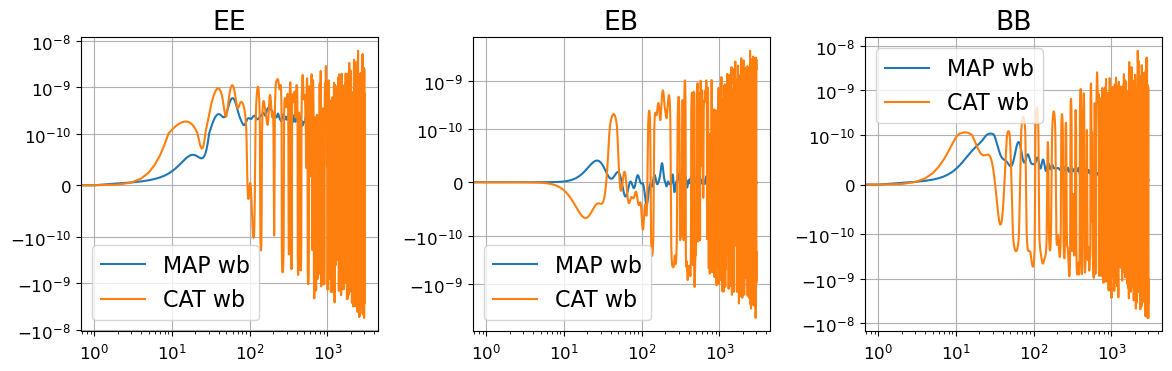

In [15]:
# list of function pairs for each panel
func_pairs = [
    ("EE", map_cls_wb[("SHE", "SHE", 1, 1)][0,0], cat_cls_wb[("SHE", "SHE", 1, 1)][0,0]),
    ("EB", map_cls_wb[("SHE", "SHE", 1, 1)][0,1], cat_cls_wb[("SHE", "SHE", 1, 1)][0,1]),
    ("BB", map_cls_wb[("SHE", "SHE", 1, 1)][1,1], cat_cls_wb[("SHE", "SHE", 1, 1)][1,1]),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
l = np.arange(lmax+1)
for ax, (f, fa, fb) in zip(axes.flat, func_pairs):
    ax.plot(l, l*fa, label=f"MAP wb")
    ax.plot(l, l*fb, label=f"CAT wb")
    ax.set_title(f)
    ax.legend()
    ax.grid(True)
    ax.set_yscale("symlog", linthresh=1E-10)
    ax.set_xscale("log")
plt.tight_layout()
plt.show()